In [1]:
import pandas as pd
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torchvision import datasets, transforms, models
import torch.optim as optim
import torch.nn.functional as F
from PIL import Image

In [2]:
torch.cuda.is_available()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [3]:
train_dir = 'D:\\Retesh Halder\\AI-ML\\AI-ML Projects\\Tomato Leaf Disease Detection_1\\Dataset\\train'
val_dir = 'D:\\Retesh Halder\\AI-ML\\AI-ML Projects\\Tomato Leaf Disease Detection_1\\Dataset\\valid'

In [4]:
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'valid': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

In [5]:
image_datasets = {
    'train': datasets.ImageFolder(train_dir, data_transforms['train']),
    'valid': datasets.ImageFolder(val_dir, data_transforms['valid'])
}
image_datasets

{'train': Dataset ImageFolder
     Number of datapoints: 18345
     Root location: D:\Retesh Halder\AI-ML\AI-ML Projects\Tomato Leaf Disease Detection_1\Dataset\train
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            ),
 'valid': Dataset ImageFolder
     Number of datapoints: 4585
     Root location: D:\Retesh Halder\AI-ML\AI-ML Projects\Tomato Leaf Disease Detection_1\Dataset\valid
     StandardTransform
 Transform: Compose(
                Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
                ToTensor()
                Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
            )}

In [6]:
dataloaders = {
    'train': torch.utils.data.DataLoader(image_datasets['train'], batch_size=32, shuffle=True, num_workers=4),
    'valid': torch.utils.data.DataLoader(image_datasets['valid'], batch_size=32, shuffle=False, num_workers=4)
}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'valid']}
print(dataset_sizes)

{'train': 18345, 'valid': 4585}


In [7]:
class_names = image_datasets['train'].classes
class_names

['Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [8]:
from torchvision.models import resnet18, ResNet18_Weights

model = resnet18(weights=ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 10)
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [9]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.001, momentum=0.9)   

In [10]:
model = model.to(device)
print(device)

cuda


In [11]:
# Initializing lists to store metrics for plotting later
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
num_epochs = 25

for epoch in range(num_epochs):
    for phase in ['train', 'valid']:
        if phase == 'train':
            model.train()
        else:
            model.eval()
        
        running_loss = 0.0
        running_corrects = 0
        
        for inputs, labels in dataloaders[phase]:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            
            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                
                if phase == 'train':
                    loss.backward()
                    optimizer.step()
            
            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)
        
        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        # Store metrics in the correct list
        if phase == 'train':
            train_losses.append(epoch_loss)
            train_accuracies.append(epoch_acc.item())
        else:
            val_losses.append(epoch_loss)
            val_accuracies.append(epoch_acc.item())

        print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
    
    print("Trainin Completed for Epoch {}".format(epoch+1))

train Loss: 0.3883 Acc: 0.8890
valid Loss: 0.0843 Acc: 0.9773
Trainin Completed for Epoch 1
train Loss: 0.0761 Acc: 0.9790
valid Loss: 0.0475 Acc: 0.9852
Trainin Completed for Epoch 2
train Loss: 0.0417 Acc: 0.9902
valid Loss: 0.0353 Acc: 0.9904
Trainin Completed for Epoch 3
train Loss: 0.0250 Acc: 0.9945
valid Loss: 0.0256 Acc: 0.9924
Trainin Completed for Epoch 4
train Loss: 0.0191 Acc: 0.9959
valid Loss: 0.0255 Acc: 0.9919
Trainin Completed for Epoch 5
train Loss: 0.0138 Acc: 0.9973
valid Loss: 0.0216 Acc: 0.9950
Trainin Completed for Epoch 6
train Loss: 0.0101 Acc: 0.9983
valid Loss: 0.0214 Acc: 0.9935
Trainin Completed for Epoch 7
train Loss: 0.0100 Acc: 0.9980
valid Loss: 0.0196 Acc: 0.9952
Trainin Completed for Epoch 8
train Loss: 0.0076 Acc: 0.9986
valid Loss: 0.0205 Acc: 0.9943
Trainin Completed for Epoch 9
train Loss: 0.0070 Acc: 0.9987
valid Loss: 0.0181 Acc: 0.9945
Trainin Completed for Epoch 10
train Loss: 0.0056 Acc: 0.9990
valid Loss: 0.0158 Acc: 0.9952
Trainin Completed

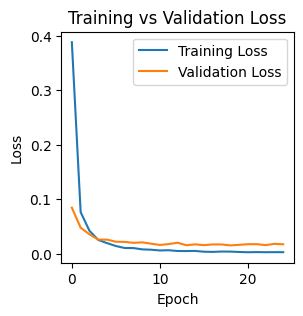

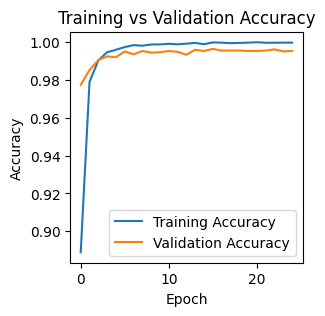

In [12]:
plt.figure(figsize=(3,3))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.show()

plt.figure(figsize=(3,3))
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.show()


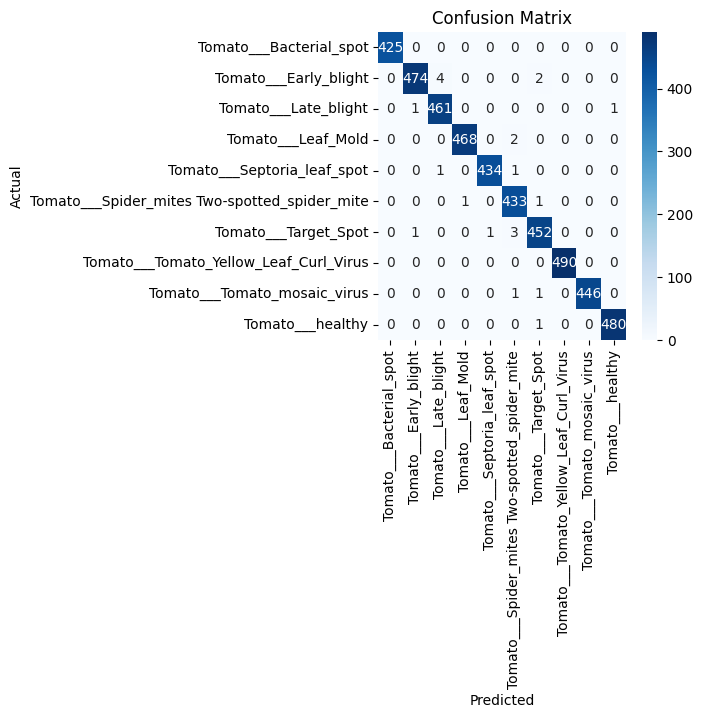

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Put model in evaluation mode
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in dataloaders['valid']:
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Create confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names
class_names = image_datasets['train'].classes

plt.figure(figsize=(4,4))
sns.heatmap(
            cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names
            )
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [16]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(all_labels, all_preds))


Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       425
           1       1.00      0.99      0.99       480
           2       0.99      1.00      0.99       463
           3       1.00      1.00      1.00       470
           4       1.00      1.00      1.00       436
           5       0.98      1.00      0.99       435
           6       0.99      0.99      0.99       457
           7       1.00      1.00      1.00       490
           8       1.00      1.00      1.00       448
           9       1.00      1.00      1.00       481

    accuracy                           1.00      4585
   macro avg       1.00      1.00      1.00      4585
weighted avg       1.00      1.00      1.00      4585



In [17]:
torch.save(model.state_dict(), "tomato_disease_model.pth", _use_new_zipfile_serialization=False)
